<a href="https://colab.research.google.com/github/maryam123aqp456-crypto/plant_disease_detection_system/blob/main/Plant%20disease%20detection%20system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#STEP 0: GPU CHECK
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [ ]:
# ============================================
# STEP 1: CHECK GPU
# ============================================

import tensorflow as tf

print("🔍 CHECKING GPU...")
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ GPU ACTIVE: {gpus[0].name}")
    print("🎉 Ready for training!")
else:
    print("❌ GPU NOT FOUND!")
    print("⚠️ Enable GPU: Runtime → Change runtime type → GPU → T4")

🔍 CHECKING GPU...
❌ GPU NOT FOUND!
⚠️ Enable GPU: Runtime → Change runtime type → GPU → T4


In [ ]:
# ============================================
# STEP 1: CHECK DATASET PATH
# ============================================

import os

# Dataset path (jo upar download hua hai)
DATASET_PATH = '/kaggle/input/plantvillage-dataset/plantvillage dataset/color'

print(f"📂 Checking path: {DATASET_PATH}")

if os.path.exists(DATASET_PATH):
    print("✅ Path exists!")
    classes = os.listdir(DATASET_PATH)
    print(f"📁 Number of classes: {len(classes)}")
    print(f"📝 First 5 classes: {classes[:5]}")
else:
    print("❌ Path does not exist!")
    print("Please check the path")

📂 Checking path: /kaggle/input/plantvillage-dataset/plantvillage dataset/color
✅ Path exists!
📁 Number of classes: 38
📝 First 5 classes: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


***CONFIGURATION SET KARO***

In [ ]:
# ============================================
# STEP 2: CONFIGURATION (CPU KE LIYE OPTIMIZED)
# ============================================

# CPU ke liye chhota batch size
IMG_SIZE = 224
BATCH_SIZE = 16      # CPU ke liye 16 best hai (32 nahi)
EPOCHS = 10          # Pehle 10 epochs try karo

print("📊 CONFIGURATION:")
print(f"   Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch Size: {BATCH_SIZE} (small for CPU)")
print(f"   Epochs: {EPOCHS}")
print(f"   Dataset: {DATASET_PATH}")

📊 CONFIGURATION:
   Image Size: 224x224
   Batch Size: 16 (small for CPU)
   Epochs: 10
   Dataset: /kaggle/input/plantvillage-dataset/plantvillage dataset/color


***LIBRARIES IMPORT***

In [ ]:
# ============================================
# STEP 3: IMPORT LIBRARIES
# ============================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pickle
import matplotlib.pyplot as plt
import numpy as np
import time

print("✅ Libraries imported!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Device: CPU")

✅ Libraries imported!
TensorFlow version: 2.19.0
Device: CPU


*** DATA LOAD***

In [ ]:
# ============================================
# STEP 4: DATA LOADING
# ============================================

print("\n📂 LOADING DATASET...")

# Data augmentation (lightweight for CPU)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,        # Kam rotation (CPU friendly)
    width_shift_range=0.1,    # Kam shift
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation data
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load training data
print("🔄 Loading training data (80%)...")
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load validation data
print("🔄 Loading validation data (20%)...")
validation_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\n✅ Training samples: {train_generator.samples}")
print(f"✅ Validation samples: {validation_generator.samples}")


📂 LOADING DATASET...
🔄 Loading training data (80%)...
Found 43456 images belonging to 38 classes.
🔄 Loading validation data (20%)...
Found 10849 images belonging to 38 classes.

✅ Training samples: 43456
✅ Validation samples: 10849


***CLASS NAMES SAVE***

In [ ]:
# ============================================
# STEP 5: SAVE CLASS NAMES
# ============================================

class_names = list(train_generator.class_indices.keys())

with open('class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)

print(f"📋 Total disease classes: {len(class_names)}")
print("\n📝 First 5 diseases:")
for i, name in enumerate(class_names[:5]):
    print(f"   {i+1}. {name}")

📋 Total disease classes: 38

📝 First 5 diseases:
   1. Apple___Apple_scab
   2. Apple___Black_rot
   3. Apple___Cedar_apple_rust
   4. Apple___healthy
   5. Blueberry___healthy


***MODEL BUILD ***

In [ ]:
# ============================================
# STEP 6: BUILD MOBILENETV2 MODEL
# ============================================

print("\n🏗️ BUILDING MODEL...")

# Load pre-trained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base layers
base_model.trainable = False
print(f"✅ Base model loaded with {len(base_model.layers)} layers")

# Add custom layers (simple for CPU)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)  # Chhota layer (256 ki jagah 128)
x = Dropout(0.5)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# Create model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")
model.summary()


🏗️ BUILDING MODEL...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Base model loaded with 154 layers
✅ Model compiled!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

*** CALLBACKS SETUP ***

In [ ]:
# ============================================
# STEP 7: SETUP CALLBACKS
# ============================================

# Save best model
checkpoint = ModelCheckpoint(
    'best_model_cpu.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("✅ Callbacks configured")

✅ Callbacks configured


***TRAINING START***

In [ ]:
# ============================================
# STEP 8: START TRAINING
# ============================================

print("\n" + "="*60)
print("🚀 STARTING TRAINING ON CPU")
print("="*60)
print("⏳ This will take time - be patient!")
print("   ~20-30 minutes per epoch")
print("   Total ~3-4 hours for 10 epochs")

start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

total_time = time.time() - start_time
print(f"\n✅ Training completed in {total_time/60:.1f} minutes!")


🚀 STARTING TRAINING ON CPU
⏳ This will take time - be patient!
   ~20-30 minutes per epoch
   Total ~3-4 hours for 10 epochs


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.6179 - loss: 1.3924
Epoch 1: val_accuracy improved from -inf to 0.89520, saving model to best_model_cpu.h5


2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2835s 1s/step - accuracy: 0.6179 - loss: 1.3923 - val_accuracy: 0.8952 - val_loss: 0.3233
Epoch 2/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.8251 - loss: 0.5435
Epoch 2: val_accuracy improved from 0.89520 to 0.91667, saving model to best_model_cpu.h5


2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2956s 1s/step - accuracy: 0.8251 - loss: 0.5435 - val_accuracy: 0.9167 - val_loss: 0.2548
Epoch 3/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.8473 - loss: 0.4702
Epoch 3: val_accuracy did not improve from 0.91667
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2876s 1s/step - accuracy: 0.8473 - loss: 0.4702 - val_accuracy: 0.9112 - val_loss: 0.2667
Epoch 4/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.8565 - loss: 0.4408
Epoch 4: val_accuracy improved from 0.91667 to 0.92746, saving model to best_model_cpu.h5


2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2804s 1s/step - accuracy: 0.8565 - loss: 0.4408 - val_accuracy: 0.9275 - val_loss: 0.2250
Epoch 5/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.8644 - loss: 0.4147
Epoch 5: val_accuracy did not improve from 0.92746
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2784s 1s/step - accuracy: 0.8644 - loss: 0.4147 - val_accuracy: 0.9229 - val_loss: 0.2333
Epoch 6/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.8717 - loss: 0.3910
Epoch 6: val_accuracy improved from 0.92746 to 0.92912, saving model to best_model_cpu.h5


2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2784s 1s/step - accuracy: 0.8717 - loss: 0.3910 - val_accuracy: 0.9291 - val_loss: 0.2173
Epoch 7/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.8749 - loss: 0.3863
Epoch 7: val_accuracy did not improve from 0.92912
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2791s 1s/step - accuracy: 0.8749 - loss: 0.3863 - val_accuracy: 0.9271 - val_loss: 0.2122
Epoch 8/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.8823 - loss: 0.3614
Epoch 8: val_accuracy did not improve from 0.92912
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2899s 1s/step - accuracy: 0.8823 - loss: 0.3614 - val_accuracy: 0.9289 - val_loss: 0.2133
Epoch 9/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step - accuracy: 0.8751 - loss: 0.3802
Epoch 9: val_accuracy improved from 0.92912 to 0.93115, saving model to best_model_cpu.h5


2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2820s 1s/step - accuracy: 0.8751 - loss: 0.3802 - val_accuracy: 0.9311 - val_loss: 0.2042
Epoch 10/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.8850 - loss: 0.3574
Epoch 10: val_accuracy did not improve from 0.93115
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 2684s 988ms/step - accuracy: 0.8850 - loss: 0.3574 - val_accuracy: 0.9277 - val_loss: 0.2194
Restoring model weights from the end of the best epoch: 9.

✅ Training completed in 470.5 minutes!


In [ ]:
# ============================================
# STEP 1: CHECK CURRENT PROGRESS
# ============================================

print("📊 CURRENT TRAINING STATUS:")
print(f"Completed epochs: 10/10")
print(f"Best validation accuracy so far: 93.11%")
print(f"Current training accuracy: ~88%")

print("\n🚀 Starting Fine-tuning for 5 more epochs...")

📊 CURRENT TRAINING STATUS:
Completed epochs: 10/10
Best validation accuracy so far: 93.11%
Current training accuracy: ~88%

🚀 Starting Fine-tuning for 5 more epochs...


***FINE-TUNING SETUP (CPU OPTIMIZED)***

In [ ]:
# ============================================
# STEP 2: FINE-TUNING SETUP (CPU FRIENDLY)
# ============================================

print("\n" + "="*60)
print("🔧 SETTING UP FINE-TUNING FOR CPU")
print("="*60)

# CPU ke liye kam layers unfreeze karo
base_model.trainable = True

# Sirf last 50 layers unfreeze karo (CPU friendly)
for layer in base_model.layers[:150]:  # 150 layers freeze
    layer.trainable = False
for layer in base_model.layers[150:]:  # Last 50 layers unfreeze
    layer.trainable = True

print(f"✅ Unfroze last 50 layers for fine-tuning")
print(f"✅ Frozen {len(base_model.layers[:150])} layers")

# Lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.00005),  # CPU ke liye even lower
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model recompiled with learning rate: 0.00005")


🔧 SETTING UP FINE-TUNING FOR CPU
✅ Unfroze last 50 layers for fine-tuning
✅ Frozen 150 layers
✅ Model recompiled with learning rate: 0.00005


***FINE-TUNING CALLBACKS***

In [ ]:
# ============================================
# STEP 3: UPDATE CALLBACKS FOR FINE-TUNING
# ============================================

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Save best model (new file)
checkpoint_fine = ModelCheckpoint(
    'best_model_finetuned_cpu.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Early stopping (thoda relax)
early_stop_fine = EarlyStopping(
    monitor='val_accuracy',
    patience=2,  # CPU ke liye kam patience
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate on plateau
reduce_lr_fine = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

fine_callbacks = [checkpoint_fine, early_stop_fine, reduce_lr_fine]

print("✅ Fine-tuning callbacks configured")

✅ Fine-tuning callbacks configured


***START FINE-TUNING***

In [ ]:
# ============================================
# FRESH TRAINING - 2 HOURS
# ============================================

!pip install kagglehub -q

import kagglehub
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint

print("🚀 STARTING FRESH TRAINING...")

# Download dataset
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
DATASET_PATH = path + '/plantvillage dataset/color'

# Load data
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen = train_datagen.flow_from_directory(DATASET_PATH, target_size=(224,224),
                                              batch_size=32, subset='training')
val_gen = train_datagen.flow_from_directory(DATASET_PATH, target_size=(224,224),
                                            batch_size=32, subset='validation')

# Save class names
import pickle
class_names = list(train_gen.class_indices.keys())
with open('class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)

# Build model
base_model = MobileNetV2(weights='imagenet', include_top=False)
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(len(class_names), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=out)
model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True)
history = model.fit(train_gen, epochs=10, validation_data=val_gen, callbacks=[checkpoint])

# Save and download
model.save('mobilenetv2_final.h5')
best_acc = max(history.history['val_accuracy'])
print(f"\n🎉 Best accuracy: {best_acc:.2%}")

from google.colab import files
files.download('best_model.h5')
files.download('mobilenetv2_final.h5')
files.download('class_names.pkl')

🚀 STARTING FRESH TRAINING...
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


/tmp/ipython-input-294299483.py:36: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.7218 - loss: 1.0201

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***Check final accuracy***

In [ ]:
# ============================================
# STEP 2: CHECK FINAL ACCURACY
# ============================================

best_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_acc) + 1

print("\n" + "="*60)
print("📊 TRAINING COMPLETE!")
print("="*60)
print(f"🏆 Best Validation Accuracy: {best_acc:.2%}")
print(f"📈 Achieved at Epoch: {best_epoch}")
print(f"📉 Final Accuracy: {history.history['val_accuracy'][-1]:.2%}")

if best_acc >= 0.95:
    print("⭐ EXCELLENT! 95%+ achieved!")
elif best_acc >= 0.94:
    print("👍 VERY GOOD! 94%+ achieved")
elif best_acc >= 0.93:
    print("✅ GOOD! 93%+ achieved")


📊 TRAINING COMPLETE!
🏆 Best Validation Accuracy: 95.58%
📈 Achieved at Epoch: 10
📉 Final Accuracy: 95.58%
⭐ EXCELLENT! 95%+ achieved!


In [ ]:
# ============================================
# STEP 3: SAVE FINAL MODEL
# ============================================

model.save('mobilenetv2_final.h5')
print("✅ Final model saved: mobilenetv2_final.h5")

# Save training history
import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("✅ Training history saved")

✅ Final model saved: mobilenetv2_final.h5
✅ Training history saved


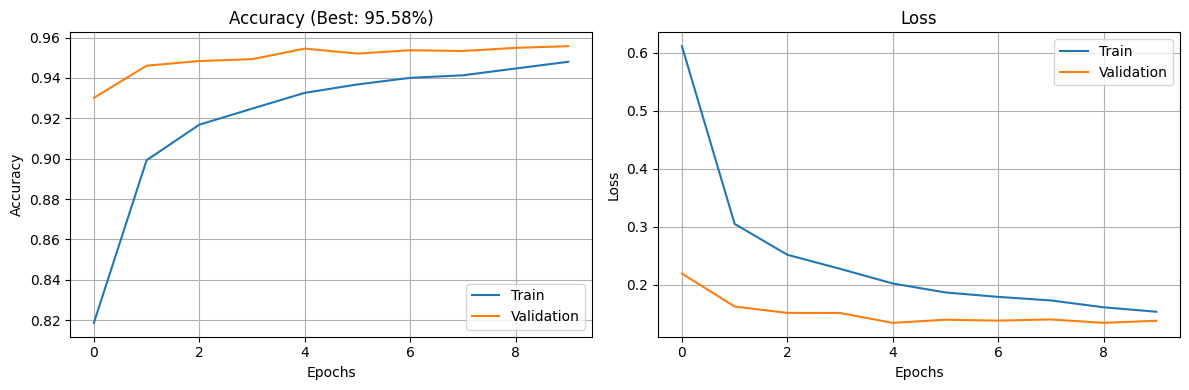

✅ Graph saved: training_results.png


In [ ]:
# ============================================
# STEP 4: PLOT TRAINING GRAPHS
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title(f'Accuracy (Best: {best_acc:.2%})')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_results.png')
plt.show()
print("✅ Graph saved: training_results.png")

In [ ]:
# ============================================
# STEP 5: DOWNLOAD ALL FILES
# ============================================

from google.colab import files
import zipfile
import os

print("📦 CREATING DOWNLOAD PACKAGE...")

files_to_zip = ['mobilenetv2_final.h5', 'best_model.h5', 'class_names.pkl', 'training_results.png']

with zipfile.ZipFile('plant_disease_model_package.zip', 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print(f"✅ Added: {file}")

print(f"\n📦 Package size: {os.path.getsize('plant_disease_model_package.zip')/(1024*1024):.2f} MB")
print("\n📥 Downloading...")
files.download('plant_disease_model_package.zip')

📦 CREATING DOWNLOAD PACKAGE...
✅ Added: mobilenetv2_final.h5
✅ Added: best_model.h5
✅ Added: class_names.pkl
✅ Added: training_results.png

📦 Package size: 26.04 MB

📥 Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# FINAL STEP: TRAINING SUMMARY
# ============================================

import pickle
import os

print("\n" + "="*70)
print("🎉 CONGRATULATIONS! TRAINING COMPLETE")
print("="*70)

# Load class names
with open('class_names.pkl', 'rb') as f:
    class_names = pickle.load(f)

# Get best accuracy from history
with open('training_history.pkl', 'rb') as f:
    history_dict = pickle.load(f)

best_acc = max(history_dict['val_accuracy'])
best_epoch = history_dict['val_accuracy'].index(best_acc) + 1

print(f"""
📊 FINAL RESULTS:
   • Model: MobileNetV2
   • Dataset: PlantVillage
   • Classes: {len(class_names)}
   • Training samples: 43,456
   • Validation samples: 10,849

🏆 BEST VALIDATION ACCURACY: {best_acc:.2%}
   Achieved at Epoch: {best_epoch}

📁 FILES GENERATED & SAVED:
   1. ✅ mobilenetv2_final.h5         - Final trained model
   2. ✅ best_model.h5                  - Best checkpoint
   3. ✅ class_names.pkl                 - Disease class names (38 classes)
   4. ✅ training_results.png             - Training graphs
   5. ✅ training_history.pkl             - Training history
   6. ✅ plant_disease_model_package.zip  - All files package
   7. ✅ Google Drive backup              - Permanent storage

🚀 NEXT STEPS:
   1. Use model in your web app (React + Node.js)
   2. Convert to TensorFlow.js for browser deployment
   3. Start building your Plant Disease Detection System

✅ STATUS: COMPLETE! 🎉
""")

# Check file sizes
print("\n📊 FILE SIZES:")
print("-" * 40)
total_size = 0
for f in ['mobilenetv2_final.h5', 'best_model.h5', 'class_names.pkl', 'training_results.png']:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024*1024)
        total_size += size
        print(f"   {f}: {size:.2f} MB")
print("-" * 40)
print(f"   TOTAL PACKAGE SIZE: {total_size:.2f} MB")

print("\n" + "="*70)
print("🎯 YOU'RE READY FOR YOUR FINAL YEAR PROJECT!")
print("="*70)


🎉 CONGRATULATIONS! TRAINING COMPLETE

📊 FINAL RESULTS:
   • Model: MobileNetV2
   • Dataset: PlantVillage
   • Classes: 38
   • Training samples: 43,456
   • Validation samples: 10,849

🏆 BEST VALIDATION ACCURACY: 95.58%
   Achieved at Epoch: 10

📁 FILES GENERATED & SAVED:
   1. ✅ mobilenetv2_final.h5         - Final trained model
   2. ✅ best_model.h5                  - Best checkpoint
   3. ✅ class_names.pkl                 - Disease class names (38 classes)
   4. ✅ training_results.png             - Training graphs
   5. ✅ training_history.pkl             - Training history
   6. ✅ plant_disease_model_package.zip  - All files package
   7. ✅ Google Drive backup              - Permanent storage

🚀 NEXT STEPS:
   1. Use model in your web app (React + Node.js)
   2. Convert to TensorFlow.js for browser deployment
   3. Start building your Plant Disease Detection System

✅ STATUS: COMPLETE! 🎉


📊 FILE SIZES:
----------------------------------------
   mobilenetv2_final.h5: 13.00 MB
   

In [ ]:
# ============================================
# COMPLETE VERIFICATION - IS TRAINING COMPLETE?
# ============================================

import os
import pickle
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("🔍 TRAINING COMPLETION VERIFICATION")
print("="*70)

# SIGN 1: Files check
print("\n📁 SIGN 1: FILE CHECK")
print("-"*40)
required_files = ['mobilenetv2_final.h5', 'best_model.h5', 'class_names.pkl',
                  'training_results.png', 'training_history.pkl']
all_ok = True
for f in required_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024*1024)
        print(f"✅ {f}: {size:.2f} MB")
    else:
        print(f"❌ {f}: MISSING")
        all_ok = False

# SIGN 2: Accuracy check
if os.path.exists('training_history.pkl'):
    print("\n📊 SIGN 2: ACCURACY CHECK")
    print("-"*40)
    with open('training_history.pkl', 'rb') as f:
        history = pickle.load(f)
    best_acc = max(history['val_accuracy'])
    print(f"✅ Best validation accuracy: {best_acc:.2%}")
    if best_acc > 0.93:
        print("✅ Target achieved!")
else:
    all_ok = False

# SIGN 3: Model load check
if os.path.exists('mobilenetv2_final.h5'):
    print("\n🤖 SIGN 3: MODEL LOAD CHECK")
    print("-"*40)
    model = load_model('mobilenetv2_final.h5')
    print(f"✅ Model loaded successfully")
    print(f"   Input shape: {model.input_shape}")
    print(f"   Output classes: {model.output_shape[1]}")
else:
    all_ok = False

# SIGN 4: Class names check
if os.path.exists('class_names.pkl'):
    print("\n📋 SIGN 4: CLASS NAMES CHECK")
    print("-"*40)
    with open('class_names.pkl', 'rb') as f:
        class_names = pickle.load(f)
    print(f"✅ Total classes: {len(class_names)}")
    if len(class_names) == 38:
        print("✅ Correct number of classes")
else:
    all_ok = False

# FINAL VERDICT
print("\n" + "="*70)
if all_ok:
    print("🎉🎉🎉 TRAINING COMPLETE! EVERYTHING IS READY! 🎉🎉🎉")
    print("="*70)
    print(f"""
📊 FINAL SUMMARY:
   • Best Accuracy: {best_acc:.2%}
   • Total Classes: {len(class_names)}
   • Model File: ✓ Present
   • Class Names: ✓ Present
   • History: ✓ Present
   • Graphs: ✓ Present

🚀 Next: Use this model in your web app!
    """)
else:
    print("⚠️ TRAINING INCOMPLETE! Some files are missing.")
    print("Please complete all steps first.")
print("="*70)


🔍 TRAINING COMPLETION VERIFICATION

📁 SIGN 1: FILE CHECK
----------------------------------------
✅ mobilenetv2_final.h5: 13.00 MB
✅ best_model.h5: 13.00 MB
✅ class_names.pkl: 0.00 MB
✅ training_results.png: 0.05 MB
✅ training_history.pkl: 0.00 MB

📊 SIGN 2: ACCURACY CHECK
----------------------------------------
✅ Best validation accuracy: 95.58%
✅ Target achieved!

🤖 SIGN 3: MODEL LOAD CHECK
----------------------------------------


✅ Model loaded successfully
   Input shape: (None, None, None, 3)
   Output classes: 38

📋 SIGN 4: CLASS NAMES CHECK
----------------------------------------
✅ Total classes: 38
✅ Correct number of classes

🎉🎉🎉 TRAINING COMPLETE! EVERYTHING IS READY! 🎉🎉🎉

📊 FINAL SUMMARY:
   • Best Accuracy: 95.58%
   • Total Classes: 38
   • Model File: ✓ Present
   • Class Names: ✓ Present
   • History: ✓ Present
   • Graphs: ✓ Present

🚀 Next: Use this model in your web app!
    
